<a href="https://colab.research.google.com/github/Ccnh120321/TN-DS-Test/blob/main/retail_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Business Problem**

ร้านค้าปลีก SME สูญเสียรายได้จากลูกค้าที่เลิกซื้อสินค้าโดยไม่ทราบล่วงหน้า

**Objective**

วิเคราะห์พฤติกรรมลูกค้าเพื่อระบุปัจจัยที่เกี่ยวข้องกับการสูญเสียลูกค้า (Customer Churn)

In [46]:
# Import library

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [22]:
# Load data to data frame

df = pd.read_csv('/content/sample_data/customer_transactions_mock.csv')
print('First 5 rows of data frame\n', df.head())
print('\nShape of data frame: ', df.shape)
print('\nData frame info:')
df.info()

First 5 rows of data frame
   customer_id  last_purchase_days  total_orders  total_spent promotion_used  \
0        C001                 5.0            20        12000            yes   
1        C002                90.0             3          800             no   
2        C003                15.0            10         4500            yes   
3        C004               120.0             2          500             no   
4        C005                30.0             8         3500            yes   

  churn  
0    no  
1   yes  
2    no  
3   yes  
4    no  

Shape of data frame:  (30, 6)

Data frame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30 non-null     object 
 1   last_purchase_days  27 non-null     float64
 2   total_orders        30 non-null     int64  
 3   total_spent         30 non-null     

# **EDA**

In [23]:
# Drop column 'custiomer_id'

df.drop('customer_id', axis=1, inplace=True)
print('First 5 rows of data frame\n', df.head())

First 5 rows of data frame
    last_purchase_days  total_orders  total_spent promotion_used churn
0                 5.0            20        12000            yes    no
1                90.0             3          800             no   yes
2                15.0            10         4500            yes    no
3               120.0             2          500             no   yes
4                30.0             8         3500            yes    no


In [24]:
# Check missing value

print('\n\nCheck missing datas:\n', df.isna().sum())
print('\n', df.describe())
df['last_purchase_days'] = df['last_purchase_days'].fillna(df['last_purchase_days'].median())
print('\n\nCheck missing datas:\n', df.isna().sum())



Check missing datas:
 last_purchase_days    3
total_orders          0
total_spent           0
promotion_used        0
churn                 0
dtype: int64

        last_purchase_days  total_orders   total_spent
count           27.000000     30.000000     30.000000
mean            33.888889      8.066667   3599.000000
std             34.678006      5.824640   3783.689451
min              1.000000      1.000000    120.000000
25%              6.000000      4.000000    800.000000
50%             18.000000      6.500000   2050.000000
75%             56.000000     10.000000   4875.000000
max            120.000000     24.000000  13500.000000


Check missing datas:
 last_purchase_days    0
total_orders          0
total_spent           0
promotion_used        0
churn                 0
dtype: int64


In [25]:
# Encode value

mapping = {
    'yes': 1,
    'no': 0
}

df['promotion_used'] = df['promotion_used'].map(mapping)
df['churn'] = df['churn'].map(mapping)
df.head()

,last_purchase_days,total_orders,total_spent,promotion_used,churn
0,5.0,20,12000,1,0
1,90.0,3,800,0,1
2,15.0,10,4500,1,0
3,120.0,2,500,0,1
4,30.0,8,3500,1,0


**วิเคราะห์การกระจายของข้อมูล**

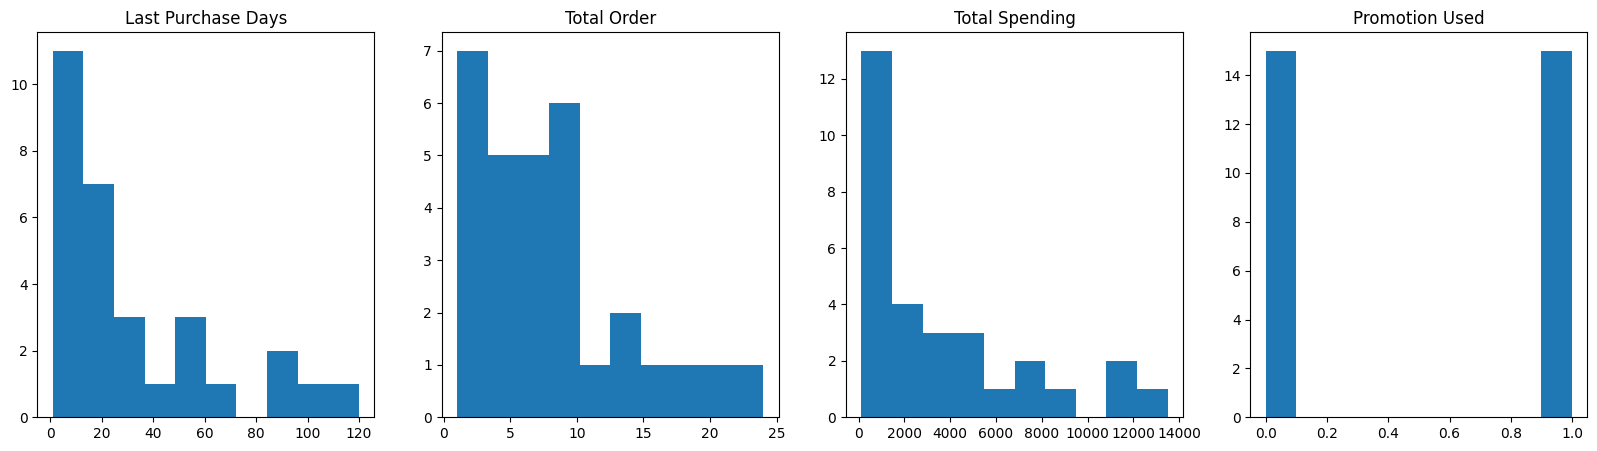

In [40]:
plt.figure(figsize=(20, 5))

plt.subplot(1,4,1)
plt.hist(df['last_purchase_days'])
plt.title('Last Purchase Days')

plt.subplot(1,4,2)
plt.hist(df['total_orders'])
plt.title('Total Order')

plt.subplot(1,4,3)
plt.hist(df['total_spent'])
plt.title('Total Spending')

plt.subplot(1,4,4)
plt.hist(df['promotion_used'])
plt.title('Promotion Used')

plt.show()

วิเคราะห์ความสัมพันธ์กับ Business **Problem**

In [47]:
display(df.groupby('churn')['last_purchase_days'].mean())
display(df.groupby('churn')['total_orders'].mean())
display(df.groupby('churn')['total_spent'].mean())
display(df.groupby('churn')['promotion_used'].mean())

,last_purchase_days
churn,
0,13.05
1,70.80


,total_orders
churn,
0,10.55
1,3.10


,total_spent
churn,
0,4995.0
1,807.0


,promotion_used
churn,
0,0.75
1,0.00


**สรุปผลการวิเคราะห์ข้อมูลเบื่องต้น (EDA)**

จากการเปรียบเทียบพฤติกรรมระหว่างลูกค้าที่ยังซื้อสินค้าอยู่(Churn=0) และลูกค้าที่เลิกซื้อสินค้าแล้ว(Churn=1) พบความแตกต่างมีดังนี้

1.ระยะเวลาตั้งแต่การซื้อครั้งล่าสุด (last_purchase_days)
*   ลูกค้าที่ยังซื้ออยู่มีค่าเฉลี่ย 13.05 วัน
*   ลูกค้าที่เลิกซื้อแล้วมีค่าเฉลี่ย 70.80 วัน

สรุป: ลูกค้าที่ไม่ได้ซื้อสินค้าเป็นเวลานานมีโอกาสที่จะเลิกซื้อสินค้าในอนาคตมากกว่า

2.จำนวนคำสั่งซื้อทั้งหมด (total_orders)
*   ลูกค้าที่ยังซื้ออยู่มีค่าเฉลี่ย 10.55 ครั้ง
*   ลูกค้าที่เลิกซื้อแล้วมีค่าเฉลี่ย 3.10 ครั้ง

สรุป: ลูกค้าที่มีความถี่ในการซื้อเยอะมีโอกาสกลับมาซื้อซ้ำและมีโอกาสที่จะเลิกซื้อสินค้าน้อยกว่า

3.ยอดใช้จ่ายรวม (total_spent)
*   ลูกค้าที่ยังซื้ออยู่มีค่าเฉลี่ย 4995 บาท
*   ลูกค้าที่เลิกซื้อแล้วมีค่าเฉลี่ย 807 บาท

สรุป: ลูกค้าที่มียอดใช้จ่ายสูงมีโอกาสที่จะอยู่เป็นลูกค้าในระยะยาว

4.การใช้โปรโมชั่น (promotion_used)
*   ลูกค้าที่ยังซื้ออยู่มีค่าเฉลี่ย 75%
*   ลูกค้าที่เลิกซื้อแล้วมีค่าเฉลี่ย 0%

สรุป: โปรโมชั่นมีส่วนช่วยให้ลูกค้ามีการกลับมาซื้อซ้ำและลดความเสี่ยงที่จะเสียลูกค้า

**ดังนั้น** ธุรกิจสามารถนำข้อมูลนี้ไปช่วยใช้ในการพัฒนา ระบบทำนายการสูญเสียลูกค้า เพื่มระบุลูกค้าที่มีความเสี่ยง และระกษาฐานลูกค้าได้